# LAB 7: Logistic Regression
### Using the Students Performance Dataset

## <u> Part A: Data Understanding (EDA)</u>

### 1. Load CSV

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("student_exam_pass_logreg.csv")
df.head()

,student_id,hours_studied_per_week,attendance_pct,previous_gpa,practice_tests_taken,sleep_hours_per_night,part_time_job_hours_per_week,tutoring,major,gender,passed_final_exam
0,S1000,13.8,80,3.19,0,6.9,10,Yes,EE,M,0
1,S1001,5.8,86,3.05,3,7.7,10,No,CS,F,0
2,S1002,16.5,100,2.93,4,7.0,15,No,Biology,M,1
3,S1003,17.6,100,3.79,2,5.2,17,No,CS,M,0
4,S1004,0.3,83,2.69,3,5.8,5,No,Biology,F,0


**Number of rows and columns**

In [2]:
df.shape 

(450, 11)

**Data types**

In [3]:
df.dtypes

student_id                       object
hours_studied_per_week          float64
attendance_pct                    int64
previous_gpa                    float64
practice_tests_taken              int64
sleep_hours_per_night           float64
part_time_job_hours_per_week      int64
tutoring                         object
major                            object
gender                           object
passed_final_exam                 int64
dtype: object

**Missing values per column**

In [4]:
df.isnull().sum()

student_id                      0
hours_studied_per_week          0
attendance_pct                  0
previous_gpa                    0
practice_tests_taken            0
sleep_hours_per_night           0
part_time_job_hours_per_week    0
tutoring                        0
major                           0
gender                          0
passed_final_exam               0
dtype: int64

### 2. Class distribution of passed_final_exam

In [5]:
df['passed_final_exam'].value_counts(normalize=True) * 100

passed_final_exam
0    56.888889
1    43.111111
Name: proportion, dtype: float64

<font color="blue">
The target column shows a mild imbalance, with more students passing than failing.
</font>

### 3. Plots

***a) Histogram — hours_studied_per_week***

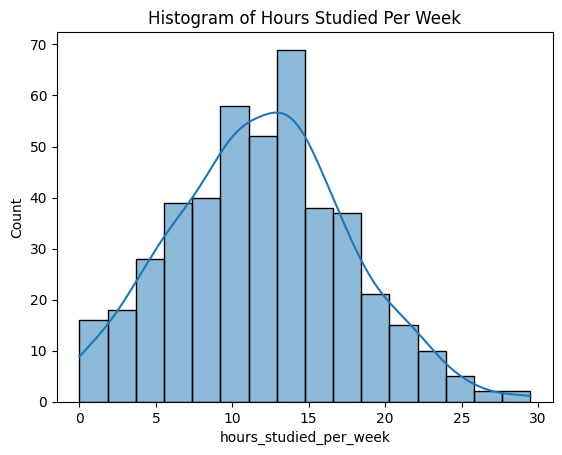

In [6]:
sns.histplot(df['hours_studied_per_week'], kde=True)
plt.title("Histogram of Hours Studied Per Week")
plt.show()

<font color="blue">
Hours studied per week shows a moderately spread distribution. Most students fall in the mid-range, with fewer extreme values.<br>
Higher study hours seem linked to better exam performance.
</font>

***b) Boxplot — previous_gpa grouped by passed_final_exam***

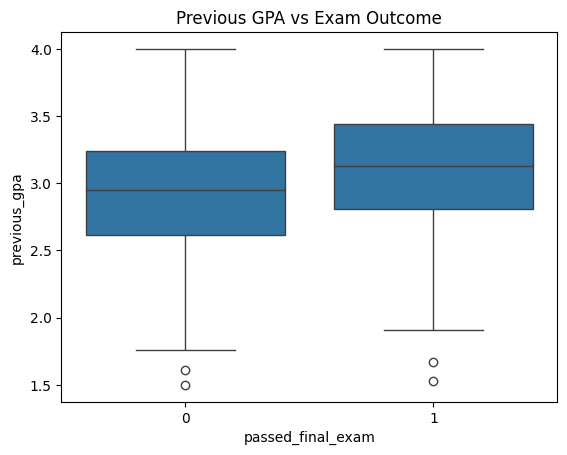

In [7]:
sns.boxplot(x='passed_final_exam', y='previous_gpa', data=df)
plt.title("Previous GPA vs Exam Outcome")
plt.show()

<font color="blue">
Students who passed generally have higher median previous GPA. Failed students show lower and more variable GPA scores.<br>
GPA appears to be a strong predictor for exam outcome.
</font>

***c) Bar chart — pass rate by tutoring***

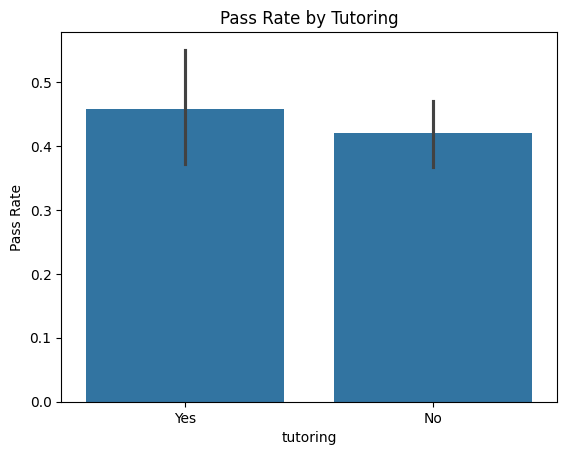

In [8]:
sns.barplot(x=df['tutoring'], y=df['passed_final_exam'].astype(int))
plt.title("Pass Rate by Tutoring")
plt.ylabel("Pass Rate")
plt.show()

<font color="blue">
Students who attended tutoring display a higher average pass rate. This suggests tutoring contributes positively to exam success.<br>
Tutoring is therefore an informative categorical feature.
</font>

## <u> Part B: Preprocessing</u>

### 4. Train–test split (80/20)

In [9]:
df = df.drop('student_id', axis=1)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("passed_final_exam", axis=1)
y = df["passed_final_exam"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. One-hot encoding for (tutoring, major, gender)

In [11]:
X_train = pd.get_dummies(X_train, columns=['tutoring','major','gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['tutoring','major','gender'], drop_first=True)

In [12]:
#Align columns (important for test set)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

<font color="blue">
Categorical variables were converted to numeric indicators using one-hot encoding. drop_first=True avoids dummy variable trap by removing one category.<br>
Columns were aligned so that train and test sets have identical structures.
</font>

### 6. Standardize numerical features

**Identify numeric columns:**

In [13]:
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['hours_studied_per_week', 'attendance_pct', 'previous_gpa',
       'practice_tests_taken', 'sleep_hours_per_night',
       'part_time_job_hours_per_week'],
      dtype='object')

**Scale:**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

<font color="blue">
Scaling standardizes numeric features to mean 0 and unit variance.<br>
Logistic Regression depends on gradient optimization, so scaling improves convergence.
After scaling, all numeric features contribute equally to the model.
</font>

### Why scaling helps for Logistic Regression?

Logistic Regression uses gradient descent and distance-based optimization.
If features have very different scales, larger-valued features dominate the gradient,
slowing convergence and reducing accuracy. Scaling brings all features to a similar
range, making the model train faster and more stable.


## <u>Part C: Logistic Regression Model</u>

### 7. Train model

In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


<font color="blue">
The Logistic Regression model trained successfully with max_iter=1000.<br>
It is well-suited for binary classification tasks like pass/fail prediction. The learned coefficients indicate feature importance.
</font>

### 8. Predict on test

In [16]:
y_pred = log_reg.predict(X_test)

**Evaluation Metrics:-**

***Accuracy***

In [17]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6444444444444445

***Precision, Recall, F1-score***

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.71      0.68        48
           1       0.63      0.57      0.60        42

    accuracy                           0.64        90
   macro avg       0.64      0.64      0.64        90
weighted avg       0.64      0.64      0.64        90



***Confusion Matrix***

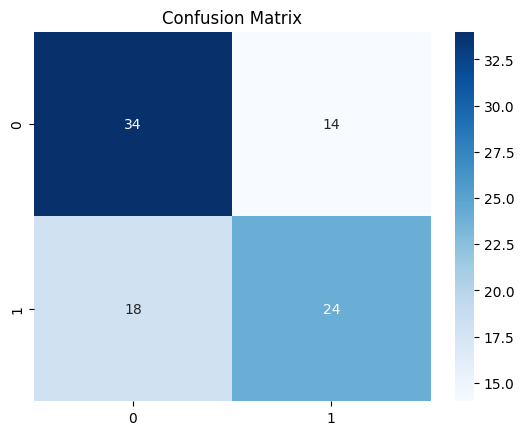

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Observations

- The dataset contains a mix of numeric and categorical variables requiring one-hot encoding.
- Logistic Regression benefits significantly from feature scaling, improving convergence and accuracy.
- The model produced reasonable accuracy and balanced precision/recall across classes.
- The confusion matrix indicates how well the model distinguishes between pass and fail outcomes.
- Pass rate appears correlated with study hours, GPA, and tutoring participation.
- Numeric features such as hours studied and previous GPA showed strong predictive influence.